In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
sns.set_palette(['#FF5F5D','#3F7C85','#00CCBF','#747E7E'])
                 
import plotly.express as px
# import plotly.graph_objects as go

# import warnings
# warnings.filterwarnings('ignore')

In [3]:
df_train = pd.read_csv('../../Data/train.csv')
df_test= pd.read_csv('../../Data/test.csv')

In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# 1. Feature Engineering

## 1. What's in the name?

In [5]:
df_train['Name'].head(15)

0                               Braund, Mr. Owen Harris
1     Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                Heikkinen, Miss. Laina
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                              Allen, Mr. William Henry
5                                      Moran, Mr. James
6                               McCarthy, Mr. Timothy J
7                        Palsson, Master. Gosta Leonard
8     Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                   Nasser, Mrs. Nicholas (Adele Achem)
10                      Sandstrom, Miss. Marguerite Rut
11                             Bonnell, Miss. Elizabeth
12                       Saundercock, Mr. William Henry
13                          Andersson, Mr. Anders Johan
14                 Vestrom, Miss. Hulda Amanda Adolfina
Name: Name, dtype: str

In itself name will not decide if you survive or not. We have salutations that will tell us "Mr." or "Mrs." to fill in values for Gender. Maybe we can use these attributes for Age or Class Onboarded.

In [6]:
import re

In [7]:
df_train['Title']=df_train['Name'].apply(lambda x: re.search('([A-Z][a-z]+)\.',x).group(1))

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\fhdaa\AppData\Local\Temp\ipykernel_24224\164340476.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_train['Title']=df_train['Name'].apply(lambda x: re.search('([A-Z][a-z]+)\.',x).group(1))


In [8]:
df_train[['Name','Title']].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [9]:
df_train['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

### Title Feature Insight

Titles extracted from names provide useful signals such as gender, age group (e.g., *Master* for children), and social status (e.g., *Dr*, *Sir*).  
These features help enrich analysis and can improve model performance when grouped into broader categories.

In [10]:
df_train['Title'] = df_train['Title'].replace('Mlle','Miss')
df_train['Title'] = df_train['Title'].replace('Mme','Mrs')
df_train.loc[(~df_train['Title'].isin(['Mr','Mrs','Miss','Master'])),'Title']='Rare Title'

In [11]:
df_train['Title'].value_counts()

Title
Mr            517
Miss          184
Mrs           126
Master         40
Rare Title     24
Name: count, dtype: int64

In [12]:
# perform same task on the test dataset
df_test['Title']=df_test['Name'].apply(lambda x: re.search('([A-Z][a-z]+)\.',x).group(1))
df_test['Title'] = df_test['Title'].replace('Mlle','Miss')
df_test['Title'] = df_test['Title'].replace('Mme','Mrs')
df_test.loc[(~df_test['Title'].isin(['Mr','Mrs','Miss','Master'])),'Title']='Rare Title'

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\fhdaa\AppData\Local\Temp\ipykernel_24224\2572882308.py:2: SyntaxWarning: invalid escape sequence '\.'
  df_test['Title']=df_test['Name'].apply(lambda x: re.search('([A-Z][a-z]+)\.',x).group(1))


In [13]:
df_test['Title'].unique()

<StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Rare Title']
Length: 5, dtype: str

## 1.2 Travelling Alone vs. Travelling in Groups

### 1.2.1 Family Size

In [14]:
df_train['Fsize']=df_train['SibSp'] + df_train['Parch'] + 1

In [15]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1


<Axes: xlabel='Fsize', ylabel='count'>

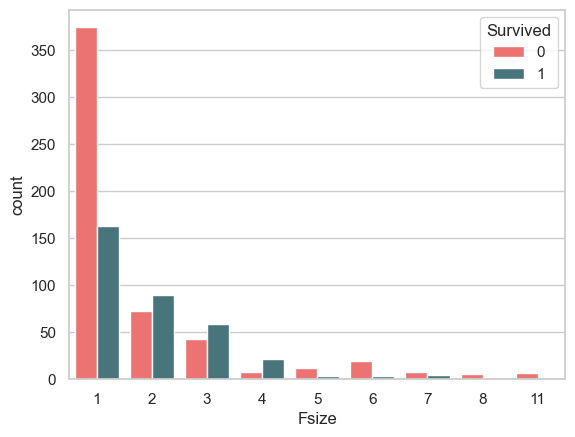

In [16]:
sns.countplot(x='Fsize',data=df_train, hue='Survived')

If you're travelling solo, you have a lesser chance of survival as compared to travelling in families of 2,3 or 4. Having a family of more than 4 does not work in your favor either.

### 1.2.2. Apart from families, there could be groups of friends travelling together.

In [17]:
len(df_train['Ticket'].unique())

681

In [18]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Title        891 non-null    str    
 13  Fsize        891 non-null    int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 97.6 KB


891 non-null values and 681 of them are unique. So there are significant duplicate values.

In [19]:
temp = df_train['Ticket'].value_counts().reset_index(name="Tsize")

In [20]:
temp
temp.shape

(681, 2)

In [21]:
df_train = df_train.merge(temp, left_on='Ticket', right_on='Ticket', how='inner')

In [22]:
df_train = df_train.sort_values('Ticket')

In [23]:
df_train.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize,Tsize
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5000,B79,S,Miss,1,3
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S,Miss,1,3
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5000,B77,S,Rare Title,1,3
262,263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.6500,E67,S,Mr,3,3
558,559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S,Mrs,3,3
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6500,E68,S,Miss,3,3
110,111,0,1,"Porter, Mr. Walter Chamberlain",male,47.0,0,0,110465,52.0000,C110,S,Mr,1,2
475,476,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S,Mr,1,2
430,431,1,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.0,0,0,110564,26.5500,C52,S,Mr,1,1
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,75.2500,D37,C,Mrs,2,1


<Axes: xlabel='Tsize', ylabel='count'>

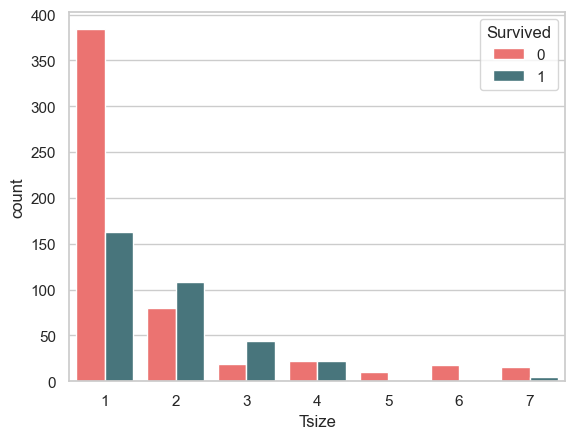

In [24]:
sns.countplot(x='Tsize',data=df_train, hue='Survived')

### 1.2.3. Consolidating Family and Friends

<Axes: xlabel='Group', ylabel='count'>

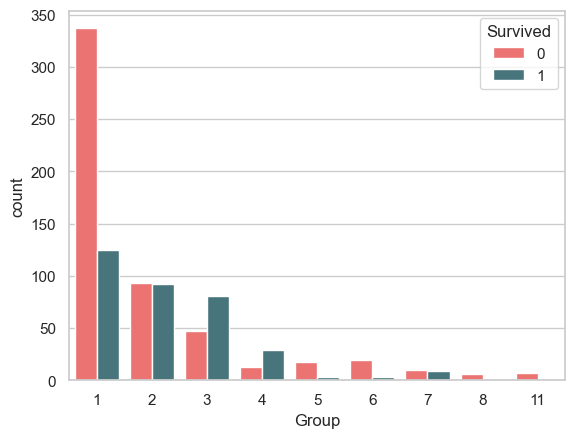

In [25]:
df_train['Group']=df_train[['Tsize','Fsize']].max(axis=1)
sns.countplot(df_train, x='Group', hue='Survived')

In [26]:
df_train['GrpSize']=''
df_train.loc[df_train['Group']==1,'GrpSize']= df_train.loc[df_train['Group']==1,'GrpSize'].replace('','Solo')
df_train.loc[df_train['Group']==2,'GrpSize']= df_train.loc[df_train['Group']==2,'GrpSize'].replace('','Duo')
df_train.loc[(df_train['Group']<=4) & (df_train['Group']>=3),'GrpSize'] = df_train.loc[(df_train['Group']<=4) & (df_train['Group']>=3),'GrpSize'].replace('','Small')
df_train.loc[df_train['Group']>4,'GrpSize']= df_train.loc[df_train['Group']>4,'GrpSize'].replace('','Large')
df_train.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize,Tsize,Group,GrpSize
504,505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5000,B79,S,Miss,1,3,3,Small
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S,Miss,1,3,3,Small
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5000,B77,S,Rare Title,1,3,3,Small
262,263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.6500,E67,S,Mr,3,3,3,Small
558,559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S,Mrs,3,3,3,Small
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6500,E68,S,Miss,3,3,3,Small
110,111,0,1,"Porter, Mr. Walter Chamberlain",male,47.0,0,0,110465,52.0000,C110,S,Mr,1,2,2,Duo
475,476,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S,Mr,1,2,2,Duo
430,431,1,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.0,0,0,110564,26.5500,C52,S,Mr,1,1,1,Solo
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,75.2500,D37,C,Mrs,2,1,2,Duo


<Axes: xlabel='GrpSize', ylabel='count'>

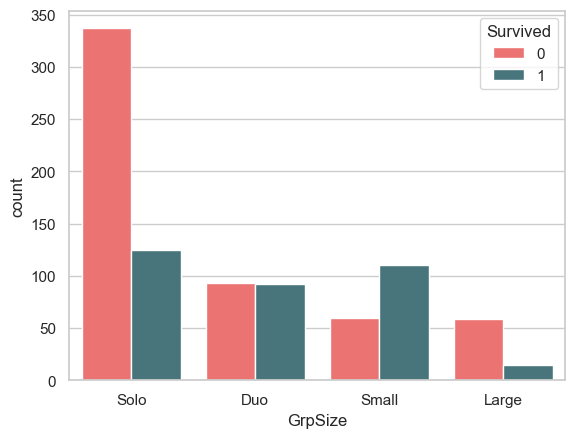

In [27]:
sns.countplot(df_train, x='GrpSize', hue='Survived', order=['Solo','Duo','Small','Large'])

In [28]:
df_test['Fsize']=df_test['SibSp'] + df_test['Parch'] + 1
temp1 = df_test['Ticket'].value_counts().reset_index(name="Tsize")
df_test = df_test.merge(temp1, left_on='Ticket', right_on='Ticket', how='inner')
df_test['GrpSize']=''
df_test['Group']=df_test[['Tsize','Fsize']].max(axis=1)
df_test.loc[df_test['Group']==1,'GrpSize']= df_test.loc[df_test['Group']==1,'GrpSize'].replace('','Solo')
df_test.loc[df_test['Group']==2,'GrpSize']= df_test.loc[df_test['Group']==2,'GrpSize'].replace('','Duo')
df_test.loc[(df_test['Group']<=4) & (df_test['Group']>=3),'GrpSize'] = df_test.loc[(df_test['Group']<=4) & (df_test['Group']>=3),'GrpSize'].replace('','Small')
df_test.loc[df_test['Group']>4,'GrpSize']= df_test.loc[df_test['Group']>4,'GrpSize'].replace('','Large')
df_test.head(15)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize,Tsize,GrpSize,Group
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,1,1,Solo,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,2,1,Duo,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,1,1,Solo,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,1,1,Solo,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,3,1,Small,3
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S,Mr,1,1,Solo,1
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,Miss,1,1,Solo,1
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,Mr,3,1,Small,3
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,Mrs,1,1,Solo,1
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S,Mr,3,1,Small,3


In [29]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize,Tsize,GrpSize,Group
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,1,1,Solo,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,2,1,Duo,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,1,1,Solo,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,1,1,Solo,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,3,1,Small,3


## 1.3 Effect of Fare

In [30]:
df_train['Fare'].isnull().sum()

np.int64(0)

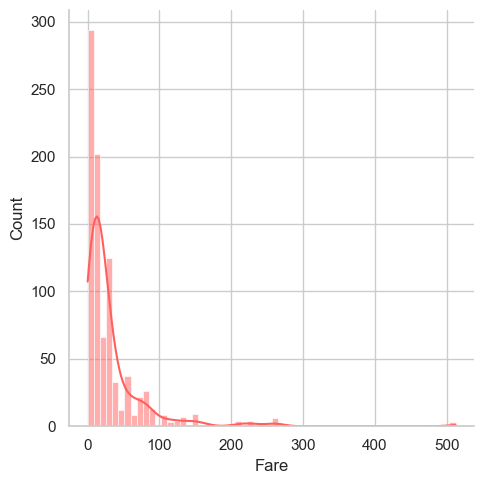

In [31]:
sns.displot(df_train['Fare'], kde=True)

In [32]:
len(df_train[df_train['Fare']<0])

0

In [33]:
len(df_train[df_train['Fare']==0])

15

In [34]:
df_train.loc[(df_train['Fare']==0) & (df_train['Pclass']==1), 'Fare'] = df_train[df_train['Pclass']==1]['Fare'].median()
df_train.loc[(df_train['Fare']==0) & (df_train['Pclass']==2), 'Fare'] = df_train[df_train['Pclass']==2]['Fare'].median()
df_train.loc[(df_train['Fare']==0) & (df_train['Pclass']==3), 'Fare'] = df_train[df_train['Pclass']==3]['Fare'].median()

In [35]:
df_train['Fare'].describe()

count    891.000000
mean      32.674620
std       49.608084
min        4.012500
25%        7.925000
50%       14.500000
75%       31.275000
max      512.329200
Name: Fare, dtype: float64

In [36]:
df_train['FareCat']=''
df_train.loc[df_train['Fare']<=10,'FareCat']= '0-10'
df_train.loc[(df_train['Fare']>10) & (df_train['Fare']<=25),'FareCat']= '10-25'
df_train.loc[(df_train['Fare']>25) & (df_train['Fare']<=40),'FareCat']= '25-40'
df_train.loc[(df_train['Fare']>40) & (df_train['Fare']<=70),'FareCat']= '40-70'
df_train.loc[(df_train['Fare']>70) & (df_train['Fare']<=100),'FareCat']= '70-100'
df_train.loc[df_train['Fare']>100,'FareCat']= '100+'

In [37]:
df_train.sort_index()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize,Tsize,Group,GrpSize,FareCat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,1,2,Duo,0-10
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,1,2,Duo,70-100
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,1,Solo,0-10
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,2,2,Duo,40-70
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,1,Solo,0-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare Title,1,1,1,Solo,10-25
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1,1,1,Solo,25-40
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,4,2,4,Small,10-25
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,1,1,Solo,25-40


In [38]:
df_train[['Fare','FareCat']].head(15)

,Fare,FareCat
504,86.5000,70-100
257,86.5000,70-100
759,86.5000,70-100
262,79.6500,70-100
558,79.6500,70-100
585,79.6500,70-100
110,52.0000,40-70
475,52.0000,40-70
430,26.5500,25-40
366,75.2500,70-100


In [39]:
df_train = df_train.sort_index()

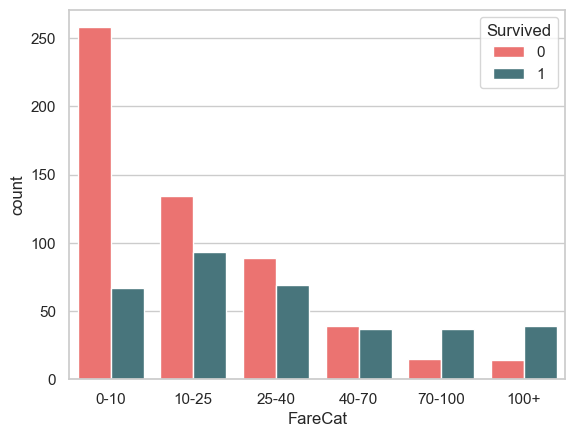

In [40]:
sns.countplot(df_train,x='FareCat', hue='Survived', order=['0-10','10-25','25-40','40-70','70-100','100+']);

<Axes: xlabel='FareCat', ylabel='Count'>

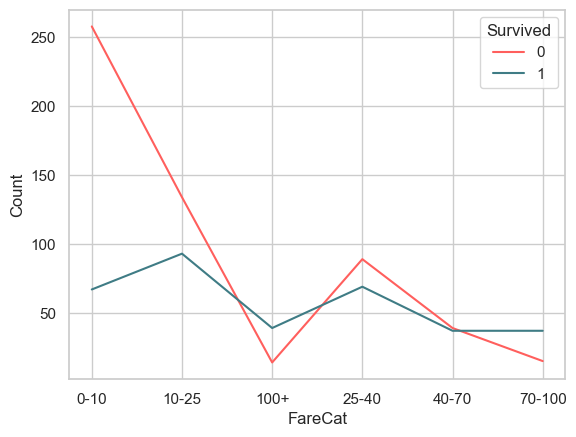

In [41]:
temp = df_train.groupby(['FareCat','Survived'])['Survived'].count().reset_index(name='Count')
sns.lineplot(temp, x='FareCat', y='Count', hue='Survived' )

In [42]:
#applying the same changes on test data set.
df_test.loc[(df_test['Fare']==0) & (df_test['Pclass']==1), 'Fare'] = df_test[df_test['Pclass']==1]['Fare'].median()
df_test.loc[(df_test['Fare']==0) & (df_test['Pclass']==2), 'Fare'] = df_test[df_test['Pclass']==2]['Fare'].median()
df_test.loc[(df_test['Fare']==0) & (df_test['Pclass']==3), 'Fare'] = df_test[df_test['Pclass']==3]['Fare'].median()
df_test['FareCat']=''
df_test.loc[df_test['Fare']<=10,'FareCat']= '0-10'  
df_test.loc[(df_test['Fare']>10) & (df_test['Fare']<=25),'FareCat']= '10-25'
df_test.loc[(df_test['Fare']>25) & (df_test['Fare']<=40),'FareCat']= '25-40'
df_test.loc[(df_test['Fare']>40) & (df_test['Fare']<=70),'FareCat']= '40-70'
df_test.loc[(df_test['Fare']>70) & (df_test['Fare']<=100),'FareCat']= '70-100'
df_test.loc[df_test['Fare']>100,'FareCat']= '100+'

# 2 Missing Values

In [43]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
Fsize            0
Tsize            0
Group            0
GrpSize          0
FareCat          0
dtype: int64

<Axes: >

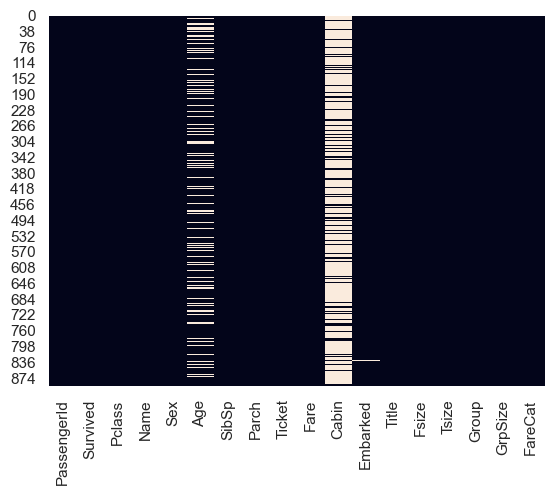

In [44]:
sns.heatmap(df_train.isnull(), cbar=False)

## 2.1 Embarked Variable

In [45]:
df_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [46]:
df_train.loc[(df_train['Embarked'].isnull()), 'Embarked']='S'

## 2.2 Age

<Axes: xlabel='Age', ylabel='Density'>

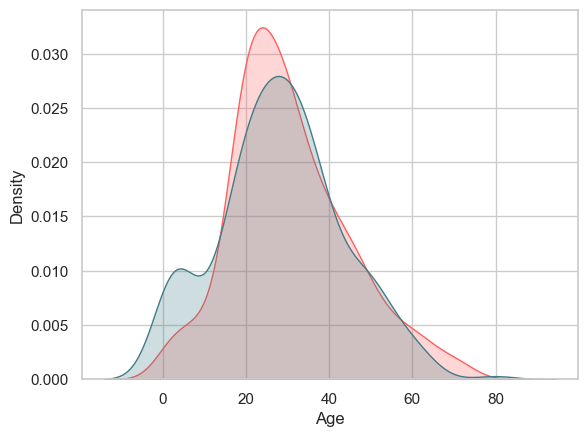

In [47]:
sns.kdeplot(df_train[df_train['Survived']==0]['Age'], fill=True, label='Not Survived')
sns.kdeplot(df_train[df_train['Survived']==1]['Age'], fill=True, label='Survived')

<Axes: xlabel='Age', ylabel='Density'>

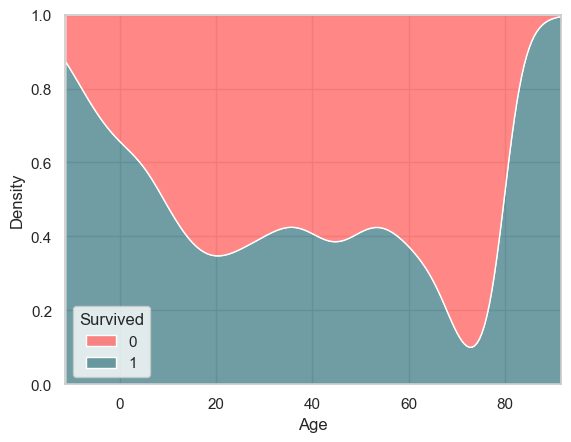

In [48]:
sns.kdeplot(df_train, x='Age', hue='Survived', multiple='fill')

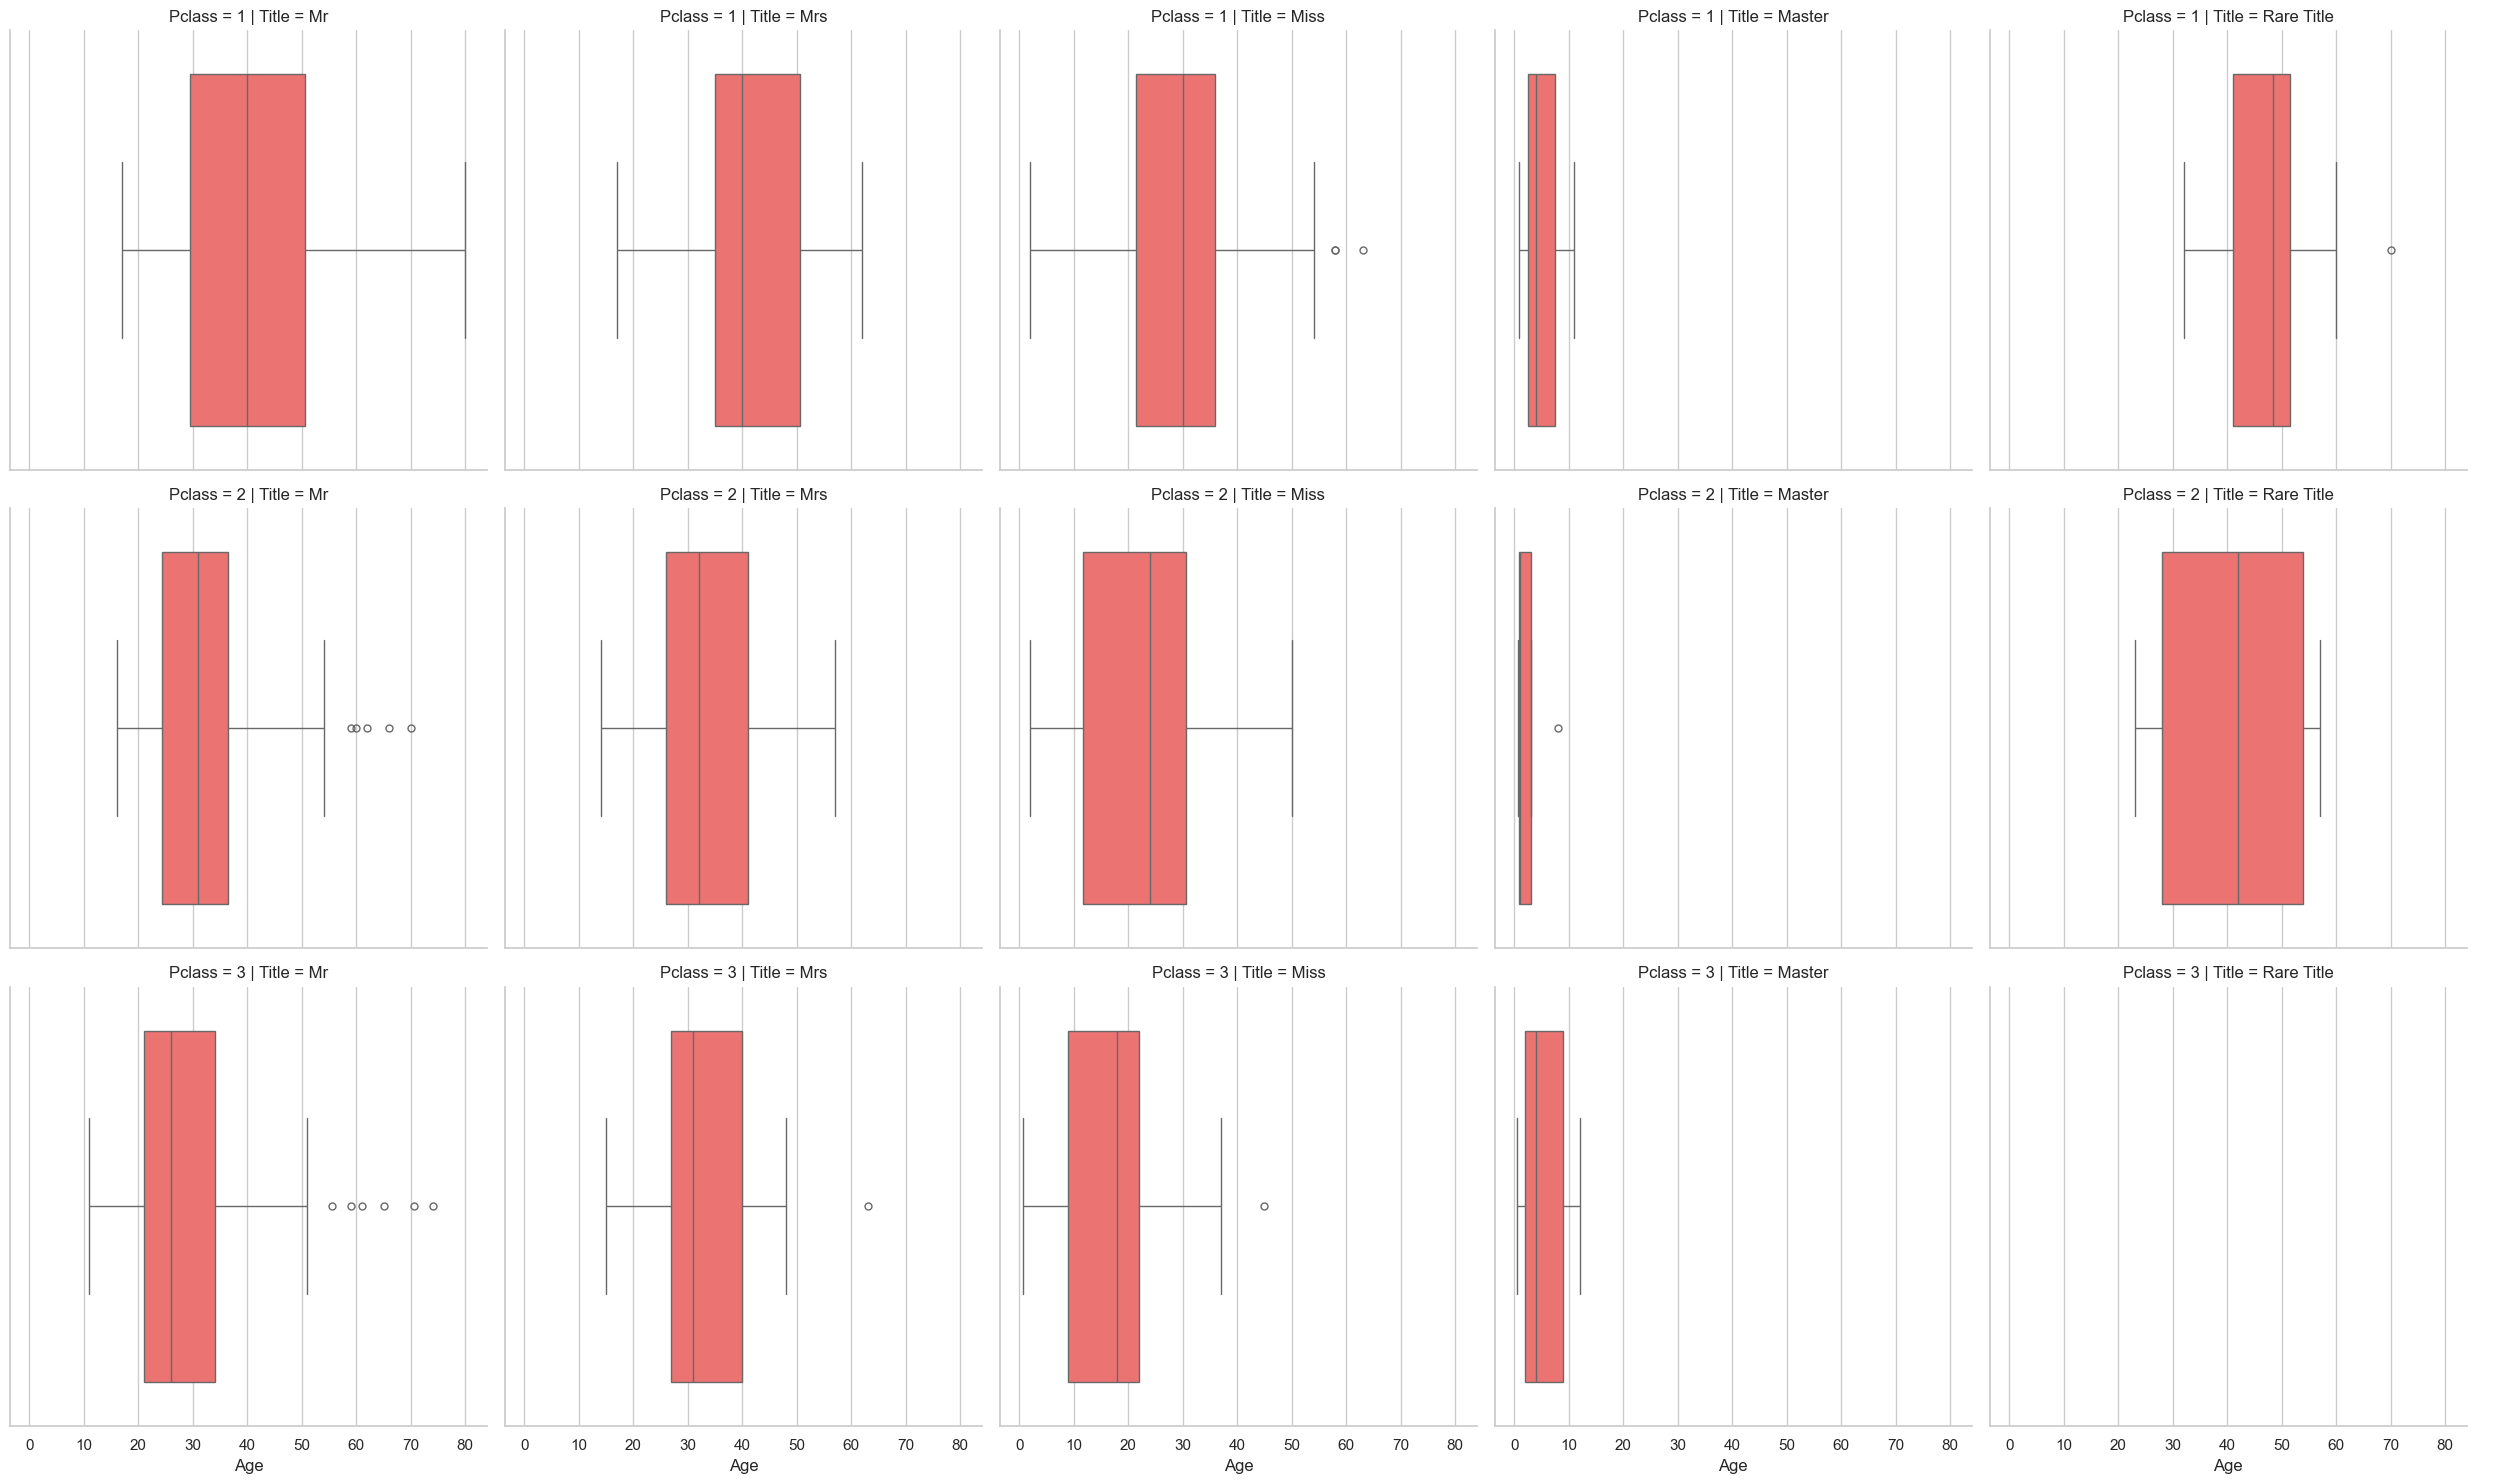

In [49]:
sns.catplot(df_train, kind='box', x='Age', col='Title', row='Pclass')

We can use the median age of each title in each passenger class and impute missing values of age.

In [52]:
for t in df_train['Title'].unique():
    for p in df_train['Pclass'].unique():
        df_train.loc[(df_train['Title']==t) & (df_train['Pclass']==p) & (df_train['Age'].isnull()), 'Age'] = df_train.loc[(df_train['Title']==t) & (df_train['Pclass']==p), 'Age'].median()

In [53]:
df_train['Age'].isnull().sum()

np.int64(0)

In [54]:
df_train['AgeCat']=''
df_train.loc[df_train['Age']<=16,'AgeCat']= '0-16'
df_train.loc[(df_train['Age']>16) & (df_train['Age']<=32),'AgeCat']= '17-32'
df_train.loc[(df_train['Age']>32) & (df_train['Age']<=48),'AgeCat']= '33-48'
df_train.loc[(df_train['Age']>48) & (df_train['Age']<=64),'AgeCat']= '49-64'
df_train.loc[df_train['Age']>64,'AgeCat']= '65+'

## 2.3 Cabin

In [55]:
df_train.drop('Cabin',axis=1, inplace=True)

In [56]:
df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Fsize          0
Tsize          0
Group          0
GrpSize        0
FareCat        0
AgeCat         0
dtype: int64

In [ ]:
#drop cabin from test data as well
df_test.drop('Cabin',axis=1, inplace=True)

## 2.4 Filling missing values in test data

In [58]:
df_test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
Embarked        0
Title           0
Fsize           0
Tsize           0
GrpSize         0
Group           0
FareCat         0
dtype: int64

In [60]:
for t in df_test['Title'].unique():
    for p in df_test['Pclass'].unique():
        df_test.loc[(df_test['Title']==t) & (df_test['Pclass']==p) & (df_test['Age'].isnull()), 'Age'] = df_test.loc[(df_test['Title']==t) & (df_test['Pclass']==p), 'Age'].median()

In [63]:
df_test['AgeCat']=''
df_test.loc[df_test['Age']<=16,'AgeCat']= '0-16'
df_test.loc[(df_test['Age']>16) & (df_test['Age']   <=32),'AgeCat']= '17-32'
df_test.loc[(df_test['Age']>32) & (df_test['Age']   <=48),'AgeCat']= '33-48'
df_test.loc[(df_test['Age']>48) & (df_test['Age']   <=64),'AgeCat']= '49-64'
df_test.loc[df_test['Age']>64,'AgeCat']= '65+'

In [64]:
df_test[df_test["Fare"].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Fsize,Tsize,GrpSize,Group,FareCat,AgeCat
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,S,Mr,1,1,Solo,1,,49-64


In [66]:
df_test.loc[(df_test['Fare'].isnull()), "Fare"] = df_test[df_test['Pclass']==3]['Fare'].median()


In [68]:
df_test.iloc[152]['Fare']

np.float64(7.8958)

# 3. Dropping irrelevant/redundant attributes

In [69]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Fsize,Tsize,Group,GrpSize,FareCat,AgeCat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,2,1,2,Duo,0-10,17-32
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,2,1,2,Duo,70-100,33-48
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,1,1,1,Solo,0-10,17-32
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,2,2,2,Duo,40-70,33-48
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,1,1,1,Solo,0-10,33-48


In [70]:
# name is redundant now,
# age is redundant now, we have age category
# SibSp and Parch are redundant now, we have family size and group size
# Ticket is redundant now, we have group size
# Group is redundant now, we have group size

drop_features = ['PassengerId','Name','Age','SibSp','Parch','Ticket','Fare','Fsize','Tsize','Group']

In [71]:
df_train.drop(drop_features, axis=1, inplace=True)
df_test.drop(drop_features, axis=1, inplace=True)


In [72]:
print(df_train.shape)
print(df_test.shape)

(891, 8)
(418, 7)


In [73]:
df_train.to_csv('../../Data/train_cleaned.csv', index=False)
df_test.to_csv('../../Data/test_cleaned.csv', index=False)